In [1]:
# Polynomial Regression
# Customer Satisfaction

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [4]:
df = pd.read_csv('3-customersatisfaction.csv')

In [5]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [6]:
df.drop("Unnamed: 0", axis = 1, inplace = True)

In [7]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


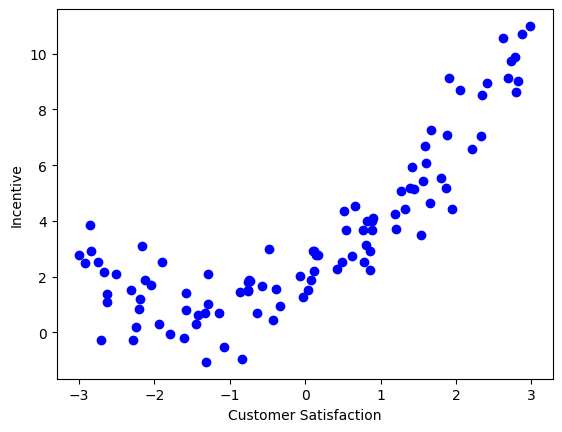

In [9]:
plt.scatter("Customer Satisfaction", "Incentive", data = df, color = "b")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.show()

In [10]:
# dependent & independent features

X = df[["Customer Satisfaction"]]
y = df[["Incentive"]]

In [11]:
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [12]:
y.head()

,Incentive
0,1.010513
1,2.281043
2,4.415053
3,10.563600
4,0.627365


In [13]:
# train - test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [14]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [15]:
# scaler
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [17]:
# regression
regression = LinearRegression()

In [18]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# predictipon

y_pred = regression.predict(X_test)

In [20]:
y_pred

array([[ 4.65663741],
       [ 3.71913877],
       [ 1.64121789],
       [ 6.29646523],
       [ 3.46766736],
       [ 5.7580845 ],
       [ 4.692485  ],
       [ 3.61616231],
       [ 5.62448003],
       [ 0.13472702],
       [ 4.47909659],
       [ 4.8130839 ],
       [ 1.58319087],
       [ 0.30515983],
       [ 5.27634309],
       [ 0.41711005],
       [-0.7385295 ],
       [-0.32653914],
       [ 3.55906887],
       [ 1.19798631]])

In [21]:
score = r2_score(y_test, y_pred)
print(score)

0.2705652535622246


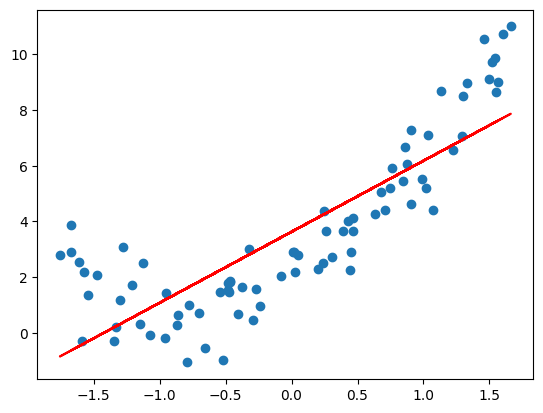

In [22]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color = "r")
plt.show()

In [23]:
poly = PolynomialFeatures(degree=2, include_bias = True)

In [24]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [25]:
X_train_poly

array([[ 1.00000000e+00,  2.47633535e-01,  6.13223675e-02],
       [ 1.00000000e+00,  1.45565669e+00,  2.11893639e+00],
       [ 1.00000000e+00, -5.40182671e-01,  2.91797318e-01],
       [ 1.00000000e+00, -7.00039198e-01,  4.90054879e-01],
       [ 1.00000000e+00,  1.56862116e+00,  2.46057233e+00],
       [ 1.00000000e+00,  9.87568378e-01,  9.75291302e-01],
       [ 1.00000000e+00,  4.48640749e-01,  2.01278522e-01],
       [ 1.00000000e+00,  1.54377517e+00,  2.38324178e+00],
       [ 1.00000000e+00,  1.33219938e+00,  1.77475518e+00],
       [ 1.00000000e+00, -4.80410926e-01,  2.30794658e-01],
       [ 1.00000000e+00,  3.92892957e-01,  1.54364876e-01],
       [ 1.00000000e+00, -6.57456685e-01,  4.32249293e-01],
       [ 1.00000000e+00,  4.42663768e-01,  1.95951211e-01],
       [ 1.00000000e+00, -8.72131603e-01,  7.60613533e-01],
       [ 1.00000000e+00, -1.57257044e+00,  2.47297780e+00],
       [ 1.00000000e+00, -4.70184630e-01,  2.21073587e-01],
       [ 1.00000000e+00, -8.36083500e-02

In [26]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.7685687698788558


In [28]:
regression.coef_

array([[0.        , 2.63871762, 1.54959954]])

In [29]:
regression.intercept_

array([2.07667643])

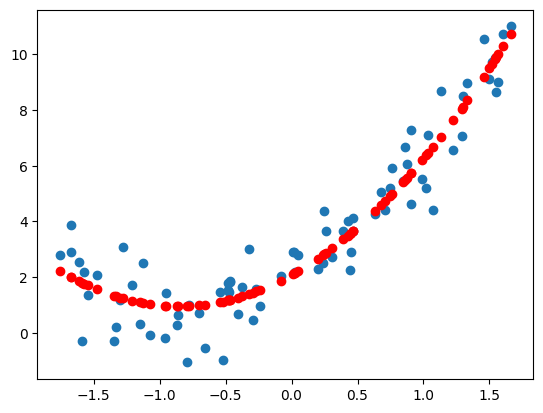

In [30]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")
plt.show()

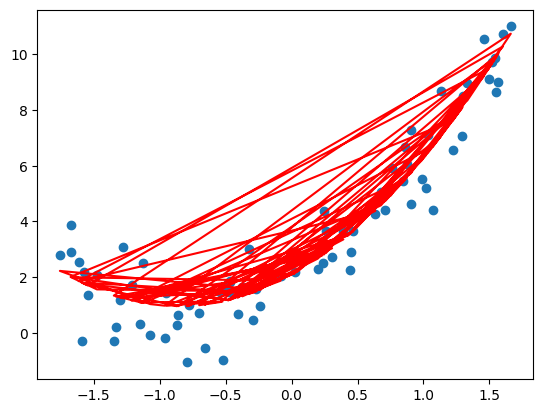

In [31]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train_poly), color = "r")
plt.show()

In [32]:
poly = PolynomialFeatures(degree=3, include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.757344362140105


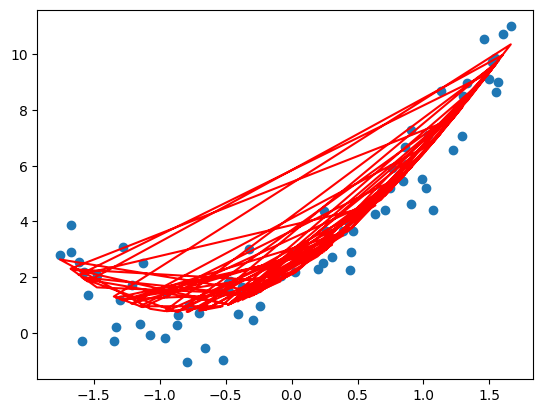

In [33]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train_poly), color = "r")
plt.show()

In [34]:
new_df = pd.read_csv("3-newdatas.csv")

In [35]:
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [36]:
new_df.rename(columns= {"0" : "Customer Satisfaction"}, inplace = True)

In [37]:
new_df

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [38]:
X_new = new_df[["Customer Satisfaction"]]

In [39]:
X_new

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [40]:
X_new = scaler.fit_transform(X_new)

In [41]:
X_new_poly = poly.transform(X_new)

In [42]:
y_new = regression.predict(X_new_poly)

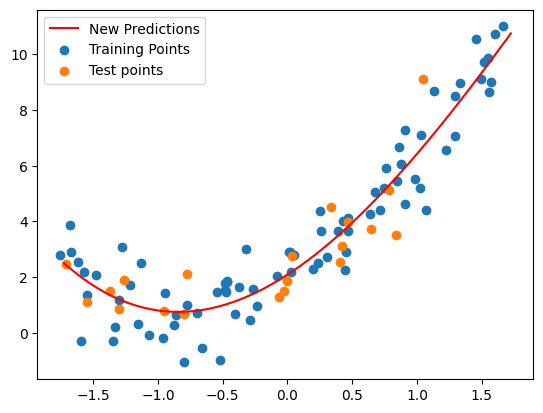

In [43]:
plt.plot(X_new, y_new, "r", label = "New Predictions")
plt.scatter(X_train, y_train, label = "Training Points")
plt.scatter(X_test, y_test, label = "Test points")
plt.legend()
plt.show()

In [44]:
# Pipeline

In [45]:
def poly_regression(degree):
    poly_features = PolynomialFeatures(degree = degree)
    lin_reg = LinearRegression()
    scaler = StandardScaler()
    pipeline = Pipeline([("standard_scaler", scaler),("poly_features", poly_features), ("lin_reg", lin_reg)])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print(f"{degree} degree of R2 score : ",score)

    y_pred_new = pipeline.predict(X_new)
    plt.plot(X_new, y_pred_new, "r", label = "New Predictions")
    plt.scatter(X_train, y_train, label = "Training Points")
    plt.scatter(X_test, y_test, label = "Test points")
    plt.legend()
    plt.show()

1 degree of R2 score :  0.2705652535622246


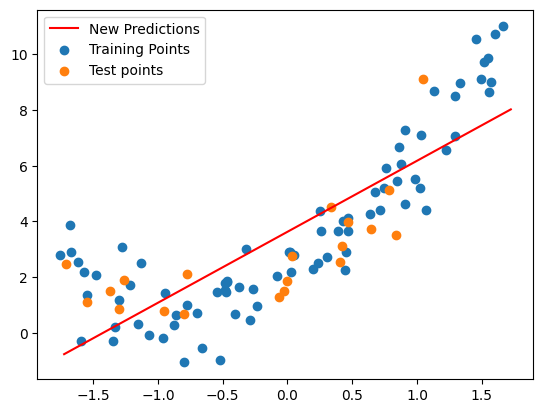

2 degree of R2 score :  0.7685687698788558


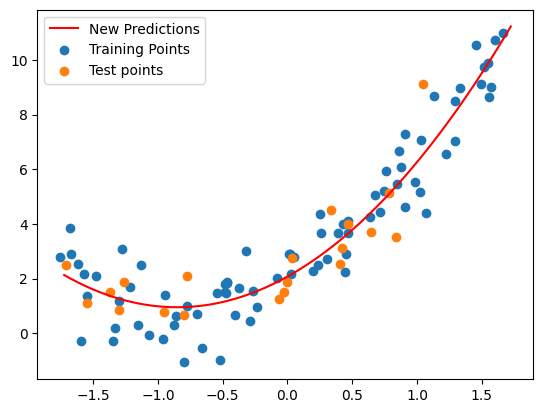

3 degree of R2 score :  0.757344362140105


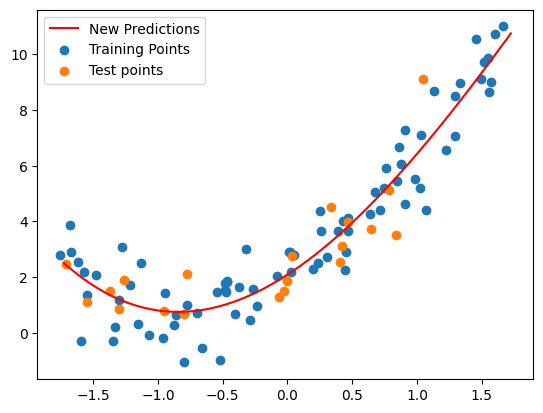

4 degree of R2 score :  0.7355034443260415


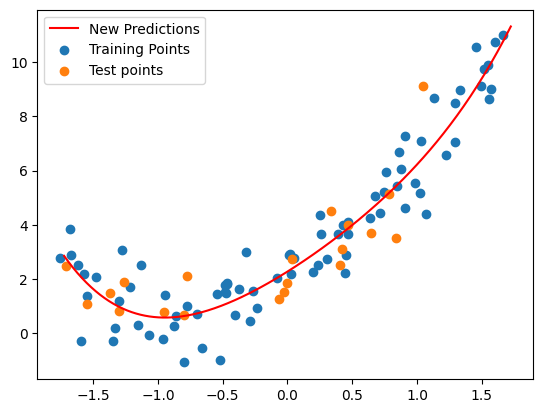

5 degree of R2 score :  0.7351244165095403


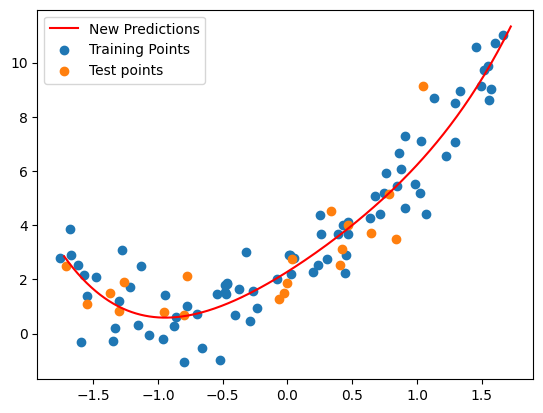

6 degree of R2 score :  0.7343590482133433


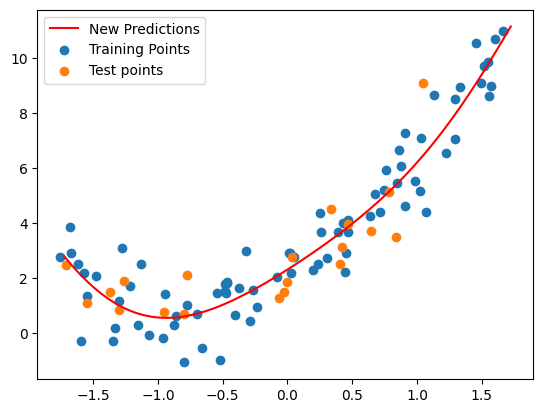

7 degree of R2 score :  0.7347819263549453


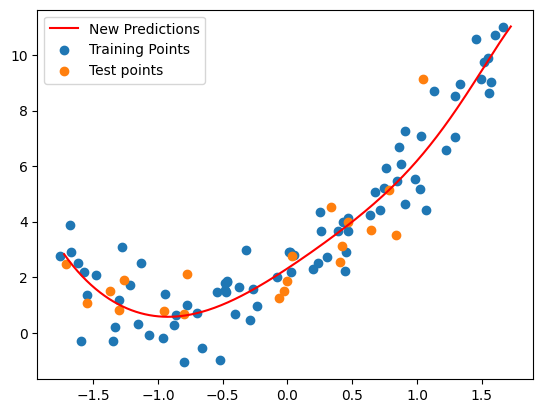

8 degree of R2 score :  0.7411422099998393


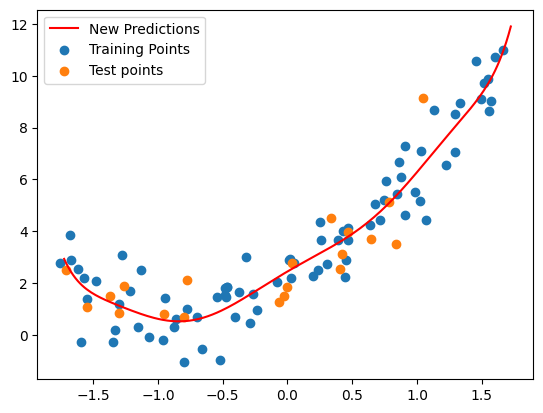

9 degree of R2 score :  0.7310763879815911


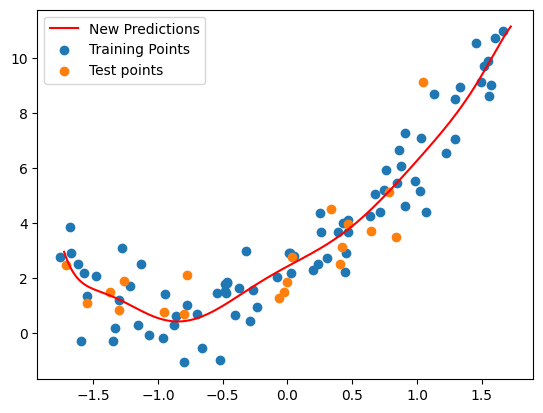

10 degree of R2 score :  0.728057862123288


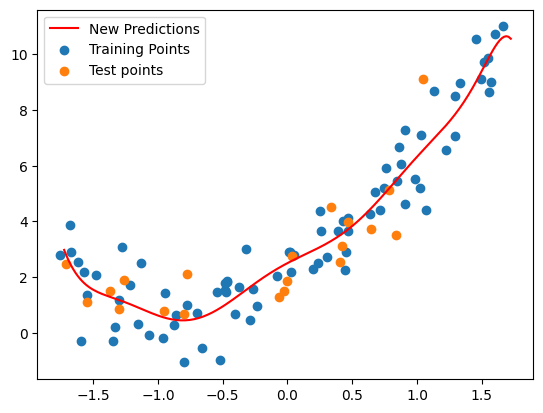

In [46]:
for degree in range(1,11):
    poly_regression(degree)